In [1]:
import os
import re
import sys
import torch
import argparse
import textwrap

import pandas as pd
import seaborn as sns
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from data import *
from utils import *
from scipy import stats
from datetime import datetime
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap
from scipy.stats import kruskal, f_oneway
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=700, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=64, help='Mini-batch size. See utils.py') #32, 64
parser.add_argument('--h_dim', type=int, default=48, help='Dim of latent vector') # 16, 24
parser.add_argument('--capacity', type=int, default=48, help='Capacity of network. See utils.py')

parser.add_argument('--x_fdim', type=int, default=256, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=64, help='Input y_fdim. See utils.py')
parser.add_argument('--z_fdim', type=int, default=64, help='Input z_fdim. See utils.py')

parser.add_argument('--c_accu', type=float, default=5.0, help='Weight on recons_error')
parser.add_argument('--start_iter', type=int, default=0, help='Input start_iter for training')

# Training Settings =============================
parser.add_argument('--lr', type=float, default=7e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=500, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

h_dim = opt.h_dim

In [3]:
_, xtest, ipVec_dim, nChannels = get_poem_dataloader(args=opt)

In [4]:
txt_encoder = tiktoken.get_encoding("o200k_base")
PAD = txt_encoder.eot_token

In [5]:
def kPCA(X, Y, Z, nviews=3, eps=1e-6):
    if nviews == 3:
        a = (X @ X.T + Y @ Y.T + Z @ Z.T) / nviews
    elif nviews == 2:
        a = (X @ X.T + Y @ Y.T) / nviews
    else:
        a = (X @ X.T) / nviews

    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)

    return h, s

In [6]:
model_1V = torch.load('./out/Final-1V.tar', weights_only=False)
model_2V_TS = torch.load('./out/Final-2V-TS.tar', weights_only=False)
model_2V_TL = torch.load('./out/Final-2V-TL.tar', weights_only=False)
model_3V = torch.load('./out/Final-3V.tar', weights_only=False)

In [7]:
# Single View Networks
net_text_en_1V = model_1V['net_text_en']
net_text_de_1V = model_1V['net_text_de']

# Two View Networks - Image + Sketch
net_text_en_2V_TS = model_2V_TS['net_text_en']
net_sent_en_2V_TS = model_2V_TS['net_sent_en']

net_text_de_2V_TS = model_2V_TS['net_text_de']
net_sent_de_2V_TS = model_2V_TS['net_sent_de']

# Two View Networks - Image + Label
net_text_en_2V_TL = model_2V_TL['net_text_en']
net_len_en_2V_TL = model_2V_TL['net_len_en']

net_text_de_2V_TL = model_2V_TL['net_text_de']
net_len_de_2V_TL = model_2V_TL['net_len_de']

# Three View Networks - Image + Sketch + Label
net_text_en_3V = model_3V['net_text_en']
net_sent_en_3V = model_3V['net_sent_en']
net_len_en_3V = model_3V['net_len_en']

net_text_de_3V = model_3V['net_text_de']
net_sent_de_3V = model_3V['net_sent_de']
net_len_de_3V = model_3V['net_len_de']

In [8]:
net_text_en_1V.eval()
net_text_en_2V_TS.eval()
net_sent_en_2V_TS.eval()
net_text_en_2V_TL.eval()
net_len_en_2V_TL.eval()
net_text_en_3V.eval()
net_sent_en_3V.eval()
net_len_en_3V.eval()

net_text_de_1V.eval()
net_text_de_2V_TS.eval()
net_sent_de_2V_TS.eval()
net_text_de_2V_TL.eval()
net_len_de_2V_TL.eval()
net_text_de_3V.eval()
net_sent_de_3V.eval()
net_len_de_3V.eval()

NetLenDe(
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=15, bias=True)
)

In [9]:
all_data_text, all_data_sent, all_data_len = [], [], []

text_en_1V = []
text_en_2V_TS, sent_en_2V_TS = [], []
text_en_2V_TL, len_en_2V_TL = [], []
text_en_3V, sent_en_3V, len_en_3V = [], [], []

text_de_1V = []
text_de_2V_TS, sent_de_2V_TS = [], []
text_de_2V_TL, len_de_2V_TL = [], []
text_de_3V, sent_de_3V, len_de_3V = [], [], []

text_loss_1V = []
text_loss_2V_TS, sent_loss_2V_TS, loss_2V_TS = [], [], []
text_loss_2V_TL, len_loss_2V_TL, loss_2V_TL = [], [], []
text_loss_3V, sent_loss_3V, len_loss_3V, loss_3V = [], [], [], []

In [10]:
recon_loss1 = torch.nn.CrossEntropyLoss(ignore_index=PAD)
recon_loss2 = torch.nn.MSELoss()
recon_loss3 = torch.nn.MSELoss()

In [11]:
with torch.no_grad():
    for i, (text, sent, leng) in enumerate(xtest):
        if i > 10:
            break

        text = text.to(opt.device)
        sent = sent.to(opt.device)
        leng = leng.to(opt.device)

        all_data_text.append(text.cpu())
        all_data_sent.append(sent.cpu())
        all_data_len.append(leng.cpu())

        # Single View
        text_en_1V.append(net_text_en_1V(text).cpu())

        # Two View - Image + Sketch
        text_en_2V_TS.append(net_text_en_2V_TS(text).cpu())
        sent_en_2V_TS.append(net_sent_en_2V_TS(sent).cpu())

        # Two View - Image + Label
        text_en_2V_TL.append(net_text_en_2V_TL(text).cpu())
        len_en_2V_TL.append(net_len_en_2V_TL(leng).cpu())

        # Three View - Image + Sketch + Label
        text_en_3V.append(net_text_en_3V(text).cpu())
        sent_en_3V.append(net_sent_en_3V(sent).cpu())
        len_en_3V.append(net_len_en_3V(leng).cpu())

In [12]:
# Convert lists of batch tensors to one tensor
all_data_text = torch.cat(all_data_text, dim=0)
all_data_sent = torch.cat(all_data_sent, dim=0)
all_data_len  = torch.cat(all_data_len, dim=0)

text_en_1V = torch.cat(text_en_1V, dim=0)

text_en_2V_TS = torch.cat(text_en_2V_TS, dim=0)
sent_en_2V_TS = torch.cat(sent_en_2V_TS, dim=0)

text_en_2V_TL = torch.cat(text_en_2V_TL, dim=0)
len_en_2V_TL  = torch.cat(len_en_2V_TL, dim=0)

text_en_3V = torch.cat(text_en_3V, dim=0)
sent_en_3V = torch.cat(sent_en_3V, dim=0)
len_en_3V  = torch.cat(len_en_3V, dim=0)

In [13]:
with torch.no_grad():
    for i in range(6):
        start, stop = i * 100, (i + 1) * 100

        # Get latent representations (current batch of 100 samples)
        h_1V, _ = kPCA(text_en_1V[start:stop], None, None, nviews=1)
        h_2V_TS, _ = kPCA(text_en_2V_TS[start:stop], sent_en_2V_TS[start:stop], None, nviews=2)
        h_2V_TL, _ = kPCA(text_en_2V_TL[start:stop], len_en_2V_TL[start:stop], None, nviews=2)
        h_3V, _ = kPCA(text_en_3V[start:stop], sent_en_3V[start:stop], len_en_3V[start:stop], nviews=3)

        # Calculate U // All views
        U_1V = text_en_1V[start:stop].T @ h_1V
        U_2V_TS = text_en_2V_TS[start:stop].T @ h_2V_TS
        U_2V_TL = text_en_2V_TL[start:stop].T @ h_2V_TL
        U_3V = text_en_3V[start:stop].T @ h_3V

        # Calculate V // 2V-IS and 3V only
        V_2V_TS = sent_en_2V_TS[start:stop].T @ h_2V_TS
        V_3V = sent_en_3V[start:stop].T @ h_3V

        # Calculate W // 2V-IL and 3V only
        W_2V_TL = len_en_2V_TL[start:stop].T @ h_2V_TL
        W_3V = len_en_3V[start:stop].T @ h_3V

        # Reconstruct images, sketches, labels from latent representations
        text_1V_tilde, _ = net_text_de_1V(h_1V @ U_1V.T)
        text_2V_TS_tilde, _ = net_text_de_2V_TS(h_2V_TS @ U_2V_TS.T)
        text_2V_TL_tilde, _ = net_text_de_2V_TL(h_2V_TL @ U_2V_TL.T)
        text_3V_tilde, _ = net_text_de_3V(h_3V @ U_3V.T)

        sent_2V_TS_tilde = net_sent_de_2V_TS(h_2V_TS @ V_2V_TS.T)
        sent_3V_tilde = net_sent_de_3V(h_3V @ V_3V.T)

        len_2V_TL_tilde = net_len_de_2V_TL(h_2V_TL @ W_2V_TL.T)
        len_3V_tilde = net_len_de_3V(h_3V @ W_3V.T)

        # Calculate losses
        text_true = all_data_text[start:stop]
        sent_true = all_data_sent[start:stop]
        len_true = all_data_len[start:stop]

        # x_tilde.reshape(-1, x_tilde.size(-1)), X.reshape(-1).long()

        text_loss_1V.append(recon_loss1(text_1V_tilde.reshape(-1, text_1V_tilde.size(-1)), text_true.reshape(-1).long()))
        text_loss_2V_TS.append(recon_loss1(text_2V_TS_tilde.reshape(-1, text_2V_TS_tilde.size(-1)), text_true.reshape(-1).long()))
        text_loss_2V_TL.append(recon_loss1(text_2V_TL_tilde.reshape(-1, text_2V_TL_tilde.size(-1)), text_true.reshape(-1).long()))
        text_loss_3V.append(recon_loss1(text_3V_tilde.reshape(-1, text_3V_tilde.size(-1)), text_true.reshape(-1).long()))

        sent_loss_2V_TS.append(recon_loss2(sent_2V_TS_tilde, sent_true))
        sent_loss_3V.append(recon_loss2(sent_3V_tilde, sent_true))

        len_loss_2V_TL.append(recon_loss3(len_2V_TL_tilde, len_true))
        len_loss_3V.append(recon_loss3(len_3V_tilde, len_true))

        # Store some samples for visualization
        if i == 0:
            text_de_1V = text_1V_tilde.cpu()[:,:10]
            text_de_2V_TS = text_2V_TS_tilde.cpu()[:,:10]
            text_de_2V_TL = text_2V_TL_tilde.cpu()[:,:10]
            text_de_3V = text_3V_tilde.cpu()[:,:10]

            sent_de_2V_TS = sent_2V_TS_tilde.cpu()[:10]
            sent_de_3V = sent_3V_tilde.cpu()[:10]
            
            len_de_2V_TL = len_2V_TL_tilde.cpu()[:10]
            len_de_3V = len_3V_tilde.cpu()[:10]

        print(f'Batch {i + 1}/10 processed.')

Batch 1/10 processed.
Batch 2/10 processed.
Batch 3/10 processed.
Batch 4/10 processed.
Batch 5/10 processed.
Batch 6/10 processed.


In [14]:
all_data_sent.shape

torch.Size([640, 4])

## Plotting

In [15]:
categories = ['1V', '2V-TS', '2V-TL', '3V']

text_losses = [
    torch.stack(text_loss_1V).mean(),
    torch.stack(text_loss_2V_TS).mean(),
    torch.stack(text_loss_2V_TL).mean(),
    torch.stack(text_loss_3V).mean()
]

sent_losses = [
    None,
    torch.stack(sent_loss_2V_TS).mean(),
    None,
    torch.stack(sent_loss_3V).mean()
]

len_losses = [
    None,
    None,
    torch.stack(len_loss_2V_TL).mean(),
    torch.stack(len_loss_3V).mean()
]

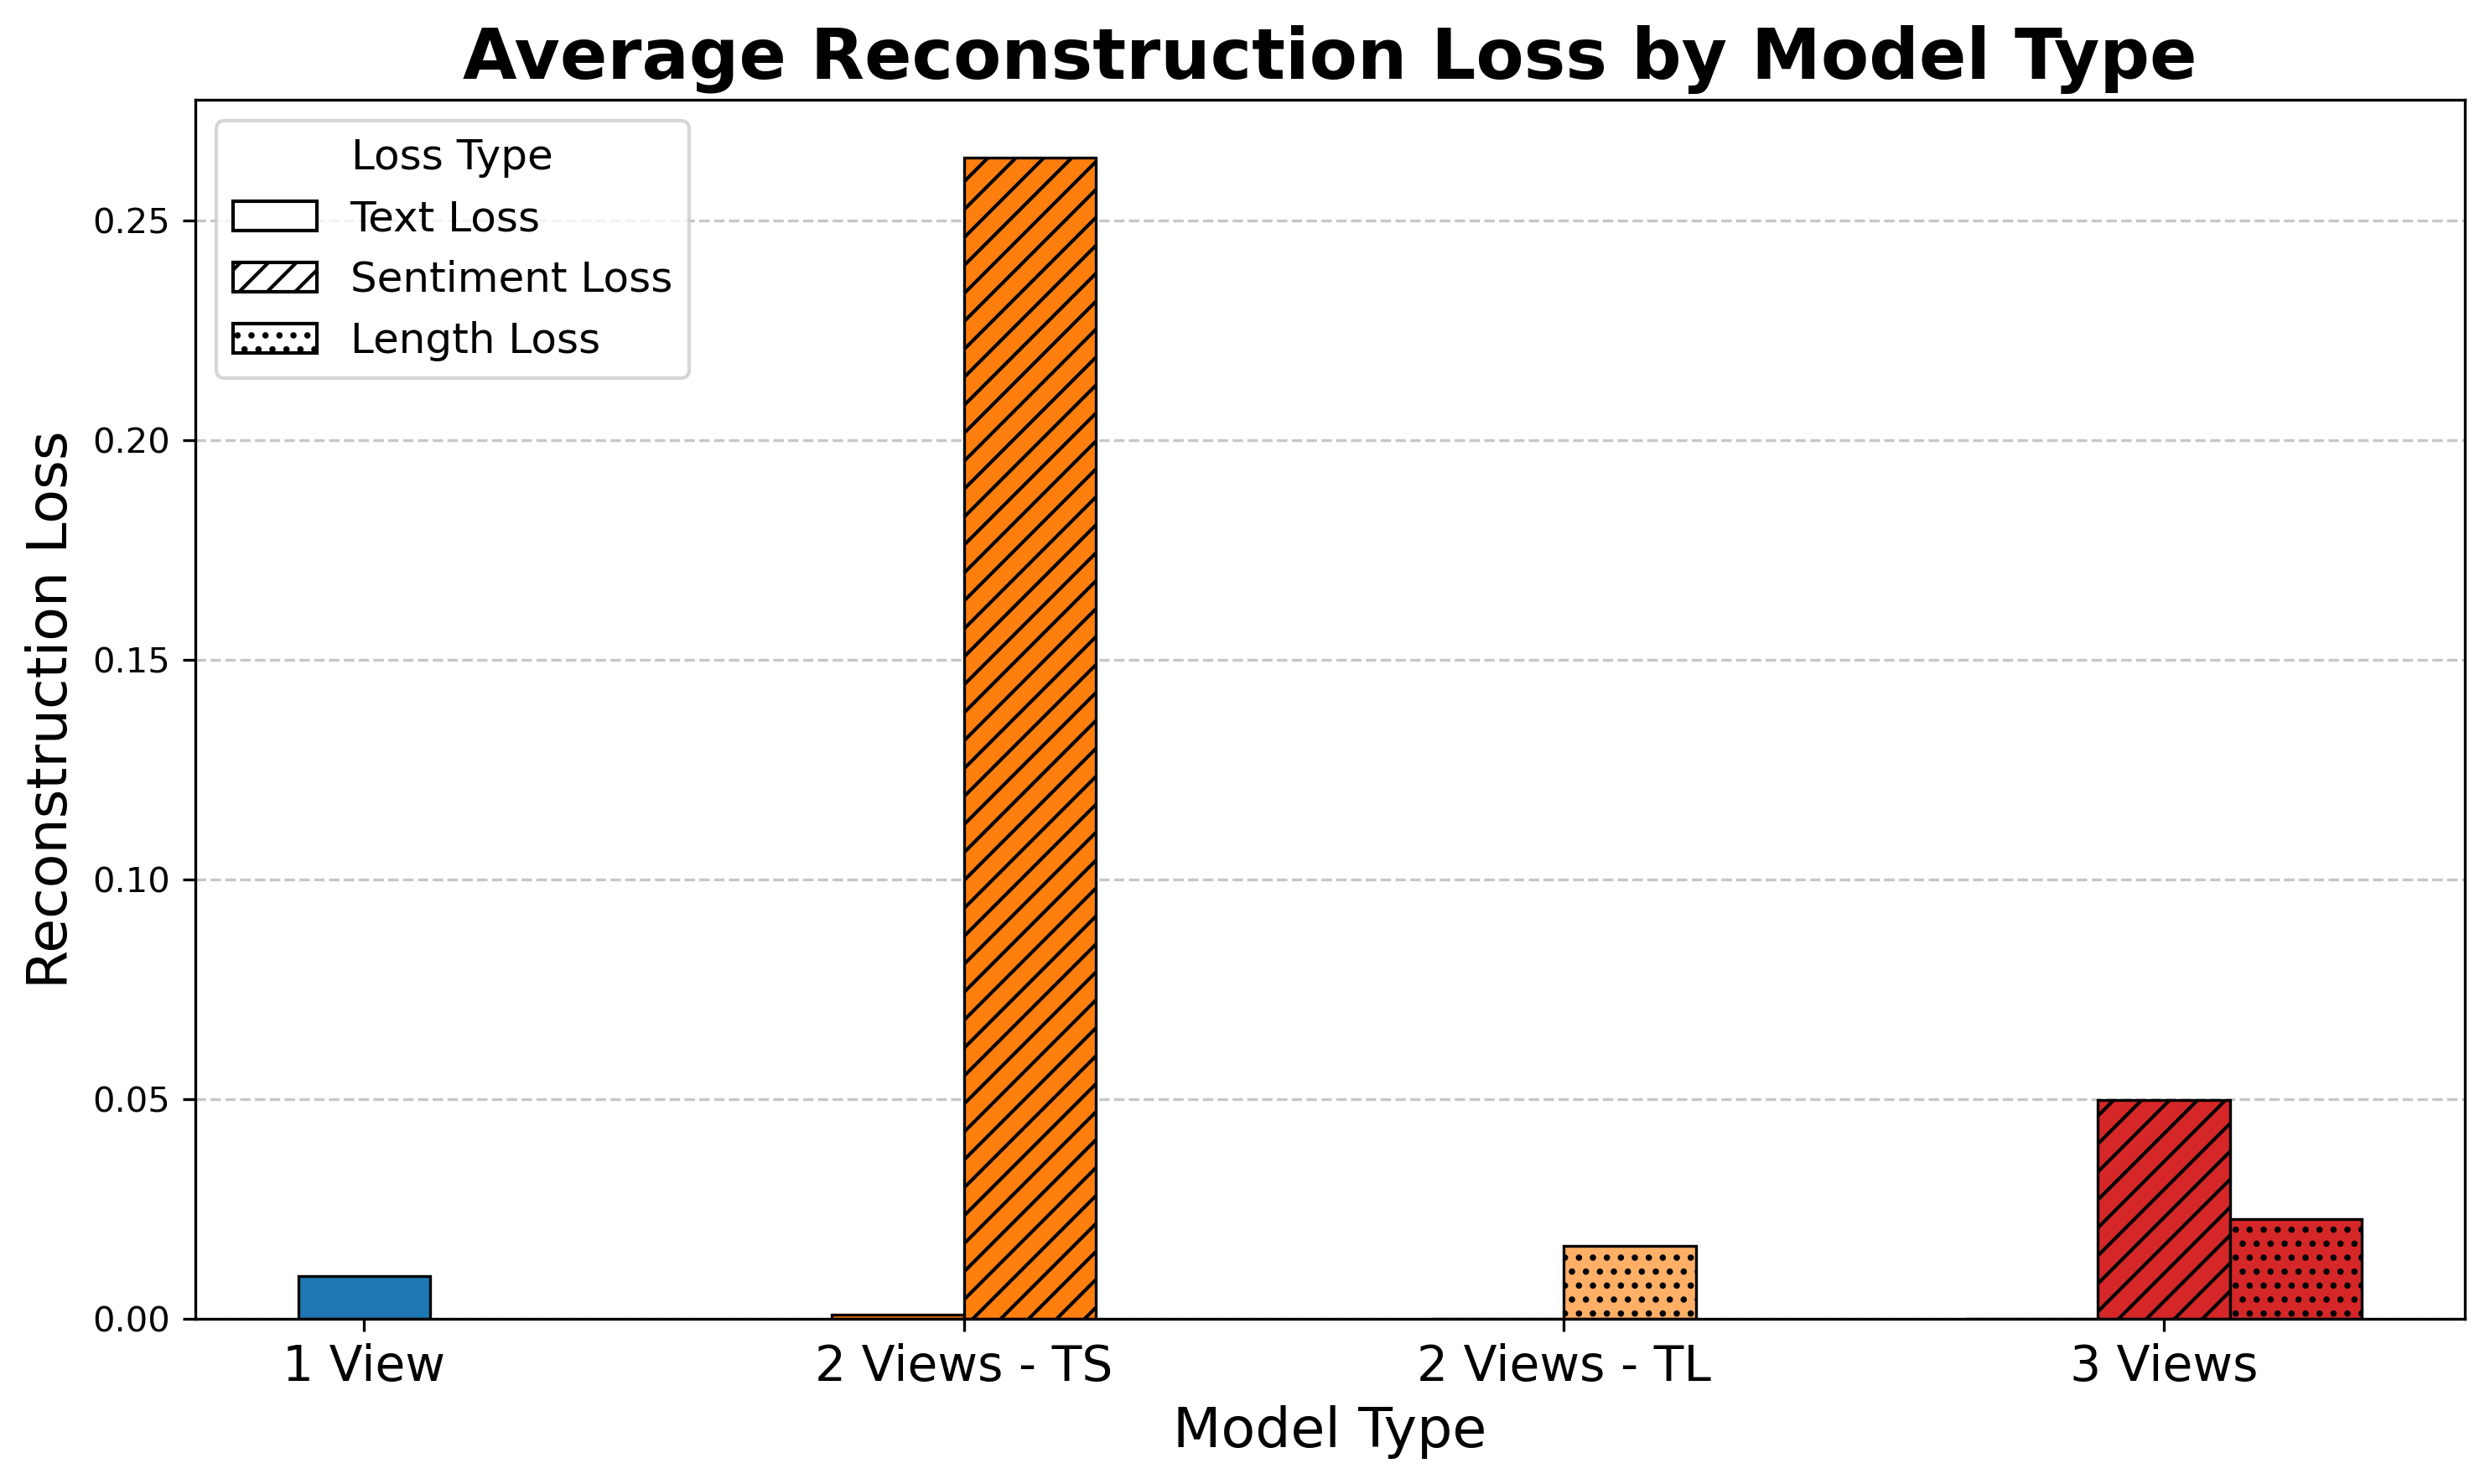

In [16]:
categories = ['1 View', '2 Views - TS', '2 Views - TL', '3 Views']
x = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bar_width = 0.22

model_color_map = {
    '1 View': 'tab:blue',
    '2 Views - TS': 'tab:orange',
    '2 Views - TL': '#ffb066',
    '3 Views': 'tab:red'
}

hatch_map = {
    'Text Loss': '',
    'Sentiment Loss': '///',
    'Length Loss': '...'
}

for i, cat in enumerate(categories):
    bars = [('Text Loss', text_losses[i].item())]

    if cat in ['2 Views - TS', '3 Views']:
        bars.append(('Sentiment Loss', sent_losses[i].item()))

    if cat in ['2 Views - TL', '3 Views']:
        bars.append(('Length Loss', len_losses[i].item()))

    n = len(bars)

    if n == 1:
        offsets = [0]
    elif n == 2:
        offsets = [-bar_width / 2, bar_width / 2]
    else:
        offsets = [-bar_width, 0, bar_width]

    for offset, (label, value) in zip(offsets, bars):
        ax.bar(
            x[i] + offset,
            value,
            bar_width,
            color=model_color_map[cat],
            hatch=hatch_map[label],
            edgecolor='black',
            linewidth=0.8
        )

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=14)
ax.set_xlabel('Model Type', fontsize=16)
ax.set_ylabel('Reconstruction Loss', fontsize=16)

plt.title('Average Reconstruction Loss by Model Type', fontsize=20, fontweight='bold')

legend_handles = [
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Text Loss'],
        label='Text Loss'
    ),
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Sentiment Loss'],
        label='Sentiment Loss'
    ),
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Length Loss'],
        label='Length Loss'
    )
]

ax.legend(
    handles=legend_handles,
    title='Loss Type',
    loc='upper left',
    fontsize=12,
    title_fontsize=12
)

ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('./img/reconstruction_loss_comparison.png', dpi=300)
plt.show()

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_77266/3318881407.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


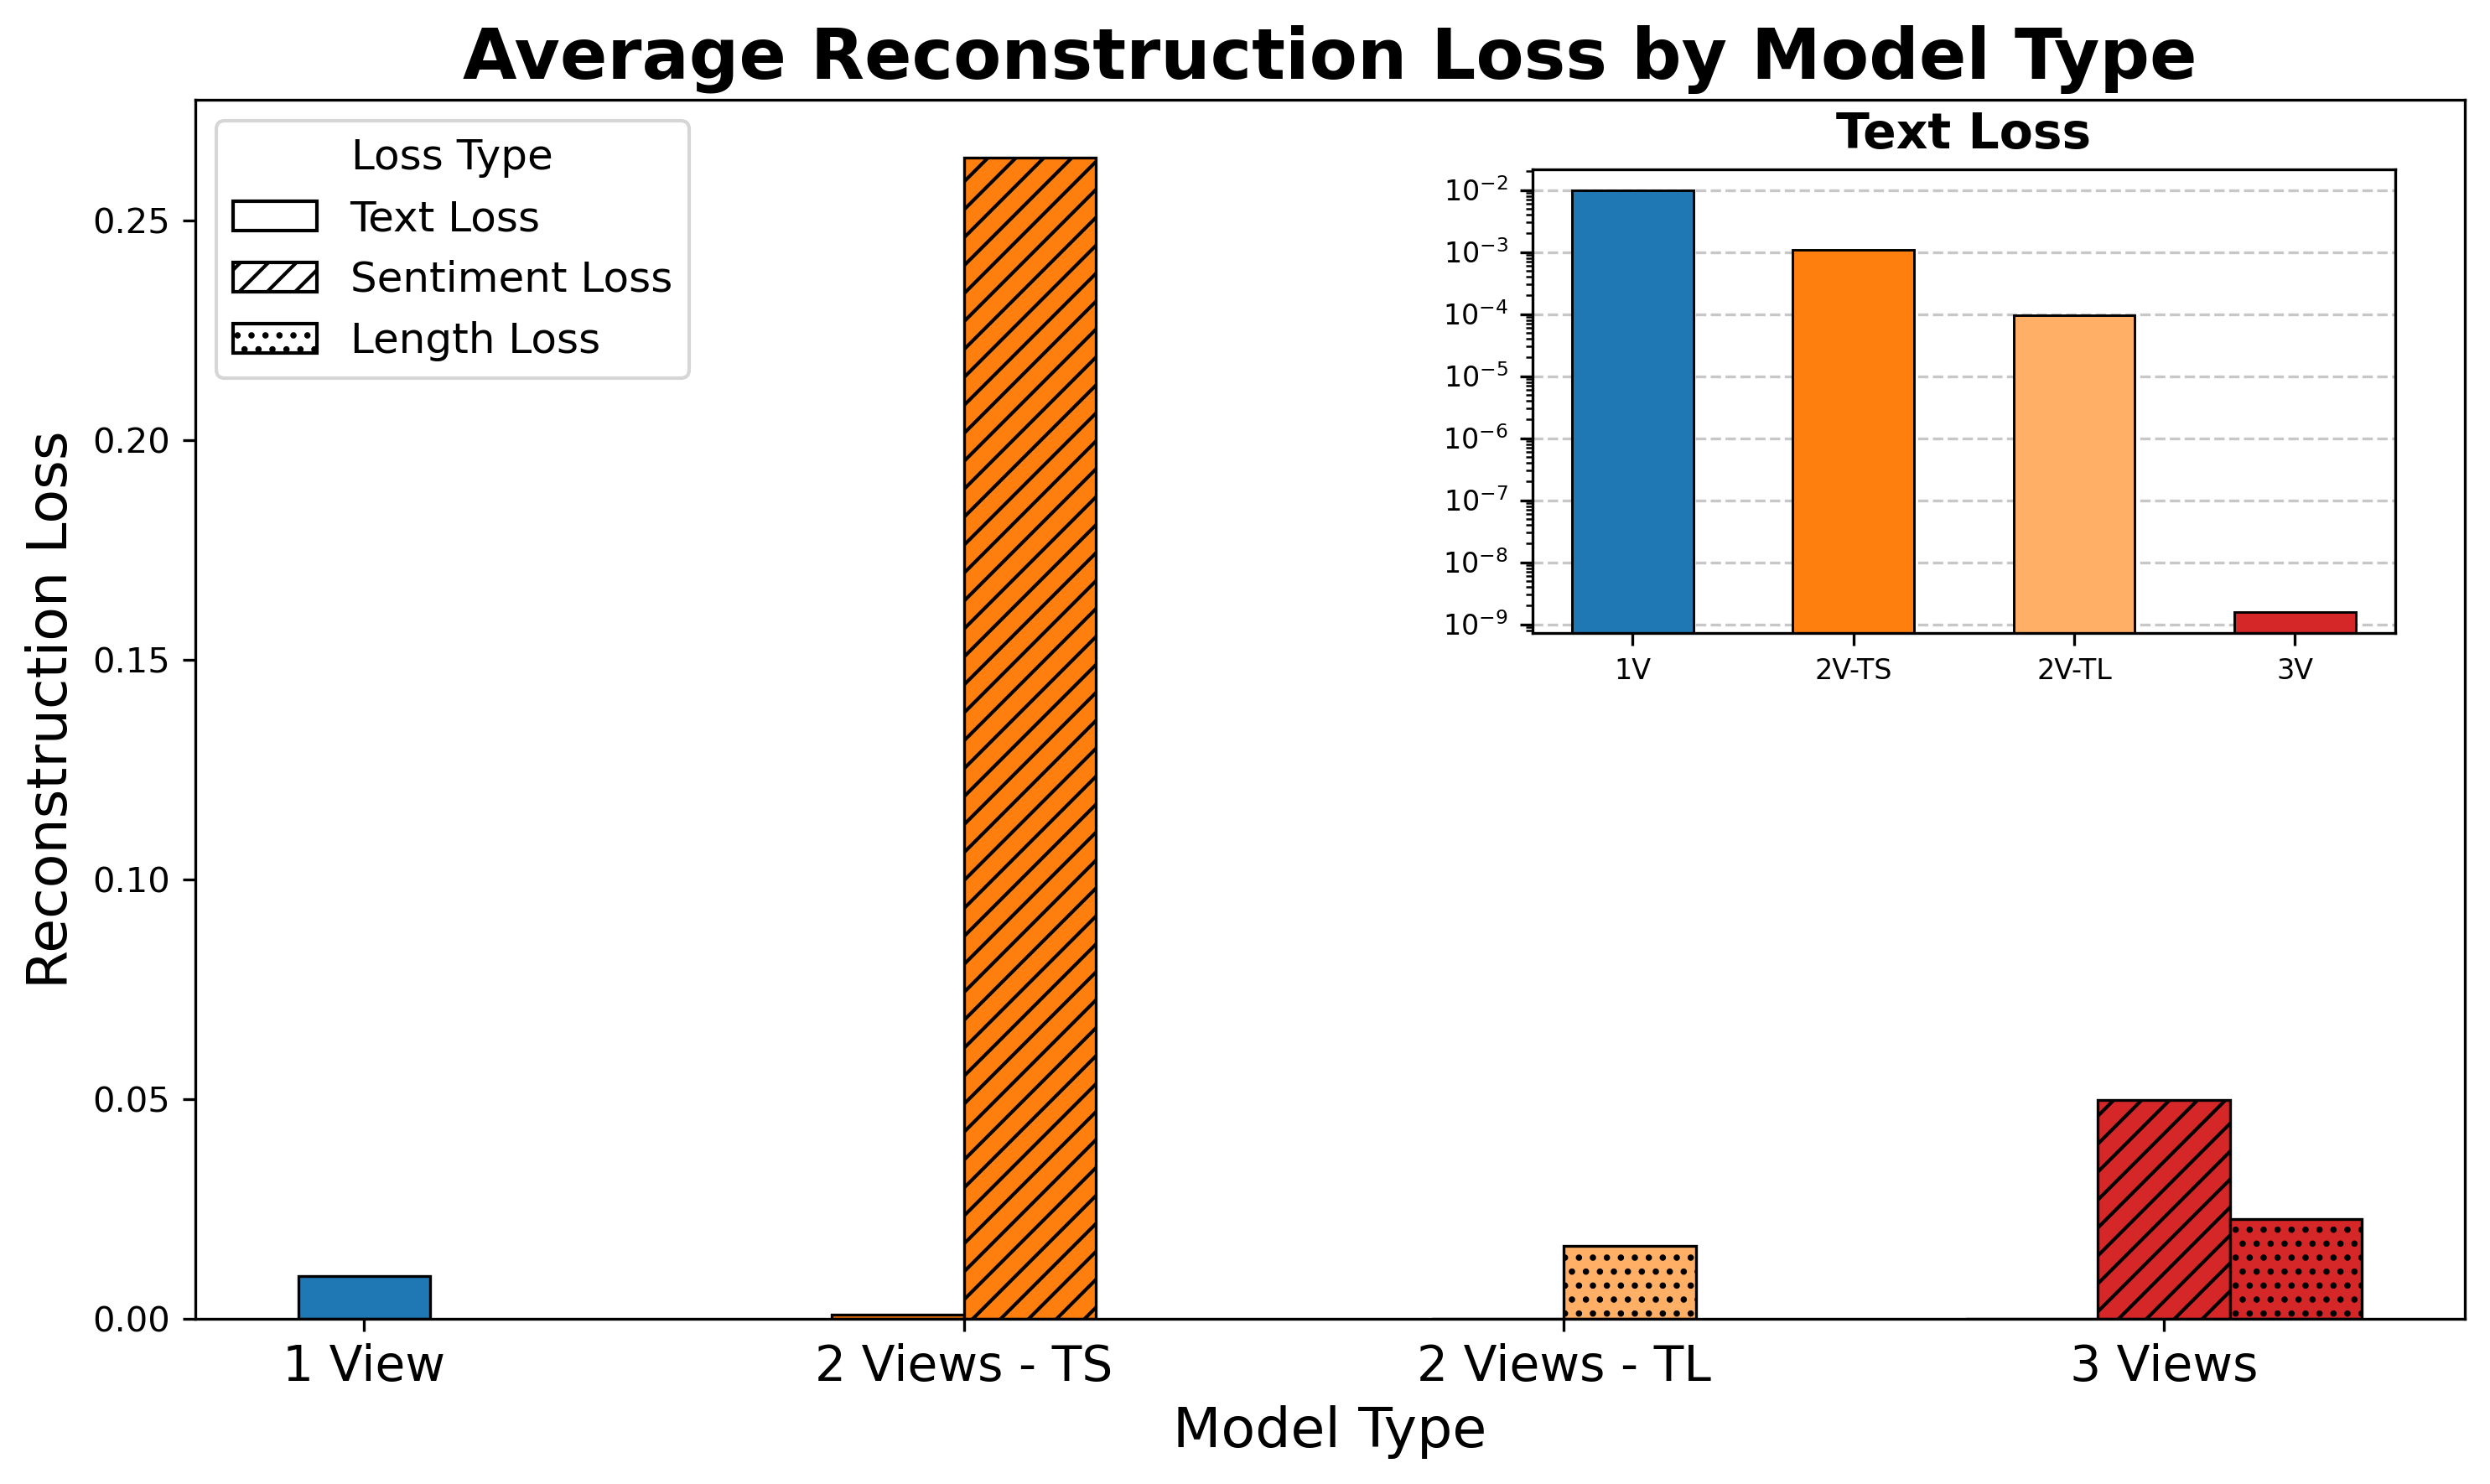

In [17]:
categories = ['1 View', '2 Views - TS', '2 Views - TL', '3 Views']
x = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bar_width = 0.22

model_color_map = {
    '1 View': 'tab:blue',
    '2 Views - TS': 'tab:orange',
    '2 Views - TL': '#ffb066',
    '3 Views': 'tab:red'
}

hatch_map = {
    'Text Loss': '',
    'Sentiment Loss': '///',
    'Length Loss': '...'
}

for i, cat in enumerate(categories):
    bars = [('Text Loss', text_losses[i].item())]

    if cat in ['2 Views - TS', '3 Views']:
        bars.append(('Sentiment Loss', sent_losses[i].item()))

    if cat in ['2 Views - TL', '3 Views']:
        bars.append(('Length Loss', len_losses[i].item()))

    n = len(bars)

    if n == 1:
        offsets = [0]
    elif n == 2:
        offsets = [-bar_width / 2, bar_width / 2]
    else:
        offsets = [-bar_width, 0, bar_width]

    for offset, (label, value) in zip(offsets, bars):
        ax.bar(
            x[i] + offset,
            value,
            bar_width,
            color=model_color_map[cat],
            hatch=hatch_map[label],
            edgecolor='black',
            linewidth=0.8
        )

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=14)
ax.set_xlabel('Model Type', fontsize=16)
ax.set_ylabel('Reconstruction Loss', fontsize=16)

plt.title('Average Reconstruction Loss by Model Type', fontsize=20, fontweight='bold')

legend_handles = [
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Text Loss'],
        label='Text Loss'
    ),
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Sentiment Loss'],
        label='Sentiment Loss'
    ),
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Length Loss'],
        label='Length Loss'
    )
]

ax.legend(
    handles=legend_handles,
    title='Loss Type',
    loc='upper left',
    fontsize=12,
    title_fontsize=12
)

# Inner bar chart with only text reconstruction losses
ax_inset = inset_axes(
    ax,
    width='38%',
    height='38%',
    loc='upper right',
    borderpad=2
)

text_values = [loss.item() for loss in text_losses]

ax_inset.bar(
    x,
    text_values,
    width=0.55,
    color=[model_color_map[cat] for cat in categories],
    edgecolor='black',
    linewidth=0.7
)

ax_inset.set_title('Text Loss', fontsize=14, fontweight='bold')
ax_inset.set_xticks(x)
ax_inset.set_xticklabels(['1V', '2V-TS', '2V-TL', '3V'], fontsize=8)
ax_inset.tick_params(axis='y', labelsize=8)
ax_inset.grid(axis='y', linestyle='--', alpha=0.7)
ax_inset.set_axisbelow(True)
ax_inset.set_yscale('log')

ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('./img/reconstruction_loss_comparison.png', dpi=300)
plt.show()

In [18]:
print(f'---- 1V Losses ----')
print(f' > Text Loss: {text_losses[0].item():.6f}')
print()
print(f'---- 2V-IS Losses ----')
print(f' > Text Loss: {text_losses[1].item():.6f}')
print(f' > Sentiment Loss: {sent_losses[1].item():.6f}')
print()
print(f'---- 2V-IL Losses ----')
print(f' > Text Loss: {text_losses[2].item():.6f}')
print(f' > Length Loss: {len_losses[2].item():.6f}')
print()
print(f'---- 3V Losses ----')
print(f' > Text Loss: {text_losses[3].item():.6f}')
print(f' > Sentiment Loss: {sent_losses[3].item():.6f}')
print(f' > Length Loss: {len_losses[3].item():.6f}')

---- 1V Losses ----
 > Text Loss: 0.009735

---- 2V-IS Losses ----
 > Text Loss: 0.001077
 > Sentiment Loss: 0.264255

---- 2V-IL Losses ----
 > Text Loss: 0.000095
 > Length Loss: 0.016714

---- 3V Losses ----
 > Text Loss: 0.000000
 > Sentiment Loss: 0.049880
 > Length Loss: 0.022645


## Statistical tests
**Null Hypothesis**: There is no difference in mean between the four groups

In [19]:
# TEst for normality of the losses using Shapiro-Wilk test
print('Shapiro-Wilk Test for Normality of Text Losses:')
for i, cat in enumerate(categories):
    if cat == '1V':
        stat, p = stats.shapiro(torch.stack(text_loss_1V).cpu().numpy())
    elif cat == '2V-IS':
        stat, p = stats.shapiro(torch.stack(text_loss_2V_TS).cpu().numpy())
    elif cat == '2V-IL':
        stat, p = stats.shapiro(torch.stack(text_loss_2V_TL).cpu().numpy())
    else:  # cat == '3V'
        stat, p = stats.shapiro(torch.stack(text_loss_3V).cpu().numpy())

    print(f' > {cat}: W-statistic = {stat:.4f}, p-value = {p:.4e}')
    print(f'   > Nomrality: {p>0.05}\n')

Shapiro-Wilk Test for Normality of Text Losses:
 > 1 View: W-statistic = 0.4961, p-value = 2.0729e-05
   > Nomrality: False

 > 2 Views - TS: W-statistic = 0.4961, p-value = 2.0729e-05
   > Nomrality: False

 > 2 Views - TL: W-statistic = 0.4961, p-value = 2.0729e-05
   > Nomrality: False

 > 3 Views: W-statistic = 0.4961, p-value = 2.0729e-05
   > Nomrality: False



In [30]:
kruskal_text = kruskal(
    torch.stack(text_loss_1V).cpu().numpy(),
    torch.stack(text_loss_2V_TS).cpu().numpy(),
    torch.stack(text_loss_2V_TL).cpu().numpy(),
    torch.stack(text_loss_3V).cpu().numpy()
)

print(f'Kruskal-Wallis Test for Text Losses: statistic = {kruskal_text.statistic:.4f}, p-value = {kruskal_text.pvalue:.4e}')

Kruskal-Wallis Test for Text Losses: statistic = 1.0126, p-value = 7.9821e-01


$p$-value $< 0.05$ => Reject Null hypothesis, concluding there is a difference between the four groups

In [21]:
text_loss_data = [
    torch.stack(text_loss_1V).cpu().numpy(),
    torch.stack(text_loss_2V_TS).cpu().numpy(),
    torch.stack(text_loss_2V_TL).cpu().numpy(),
    torch.stack(text_loss_3V).cpu().numpy()
]

tukey_results = sp.posthoc_tukey(text_loss_data)

1    a
2    a
3    a
4    a
Name: letters, dtype: str
          1         2         3         4
1  1.000000  0.521400  0.431082  0.422762
2  0.521400  1.000000  0.998561  0.998109
3  0.431082  0.998561  1.000000  0.999999
4  0.422762  0.998109  0.999999  1.000000


/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_77266/1055917553.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


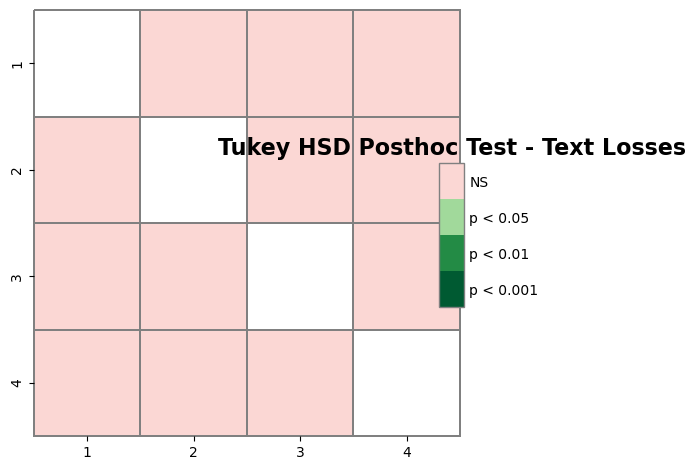

In [22]:
heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}

sp.sign_plot(tukey_results, **heatmap_args)
plt.title('Tukey HSD Posthoc Test - Text Losses', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('./img/turkey_posthoc_text_loss.png', dpi=300)

print(sp.compact_letter_display(tukey_results)) 
print(tukey_results)

## Boxplot

In [23]:
df = pd.DataFrame({
    "loss": (
        [x.item() if hasattr(x, "item") else float(x) for x in text_loss_1V] +
        [x.item() if hasattr(x, "item") else float(x) for x in text_loss_2V_TS] +
        [x.item() if hasattr(x, "item") else float(x) for x in text_loss_2V_TL] +
        [x.item() if hasattr(x, "item") else float(x) for x in text_loss_3V]
    ),
    "model": (
        ["1 Views"] * len(text_loss_1V) +
        ["2 Views - IS"] * len(text_loss_2V_TS) +
        ["2 Views - IL"] * len(text_loss_2V_TL) +
        ["3 Views"] * len(text_loss_3V)
    )
})

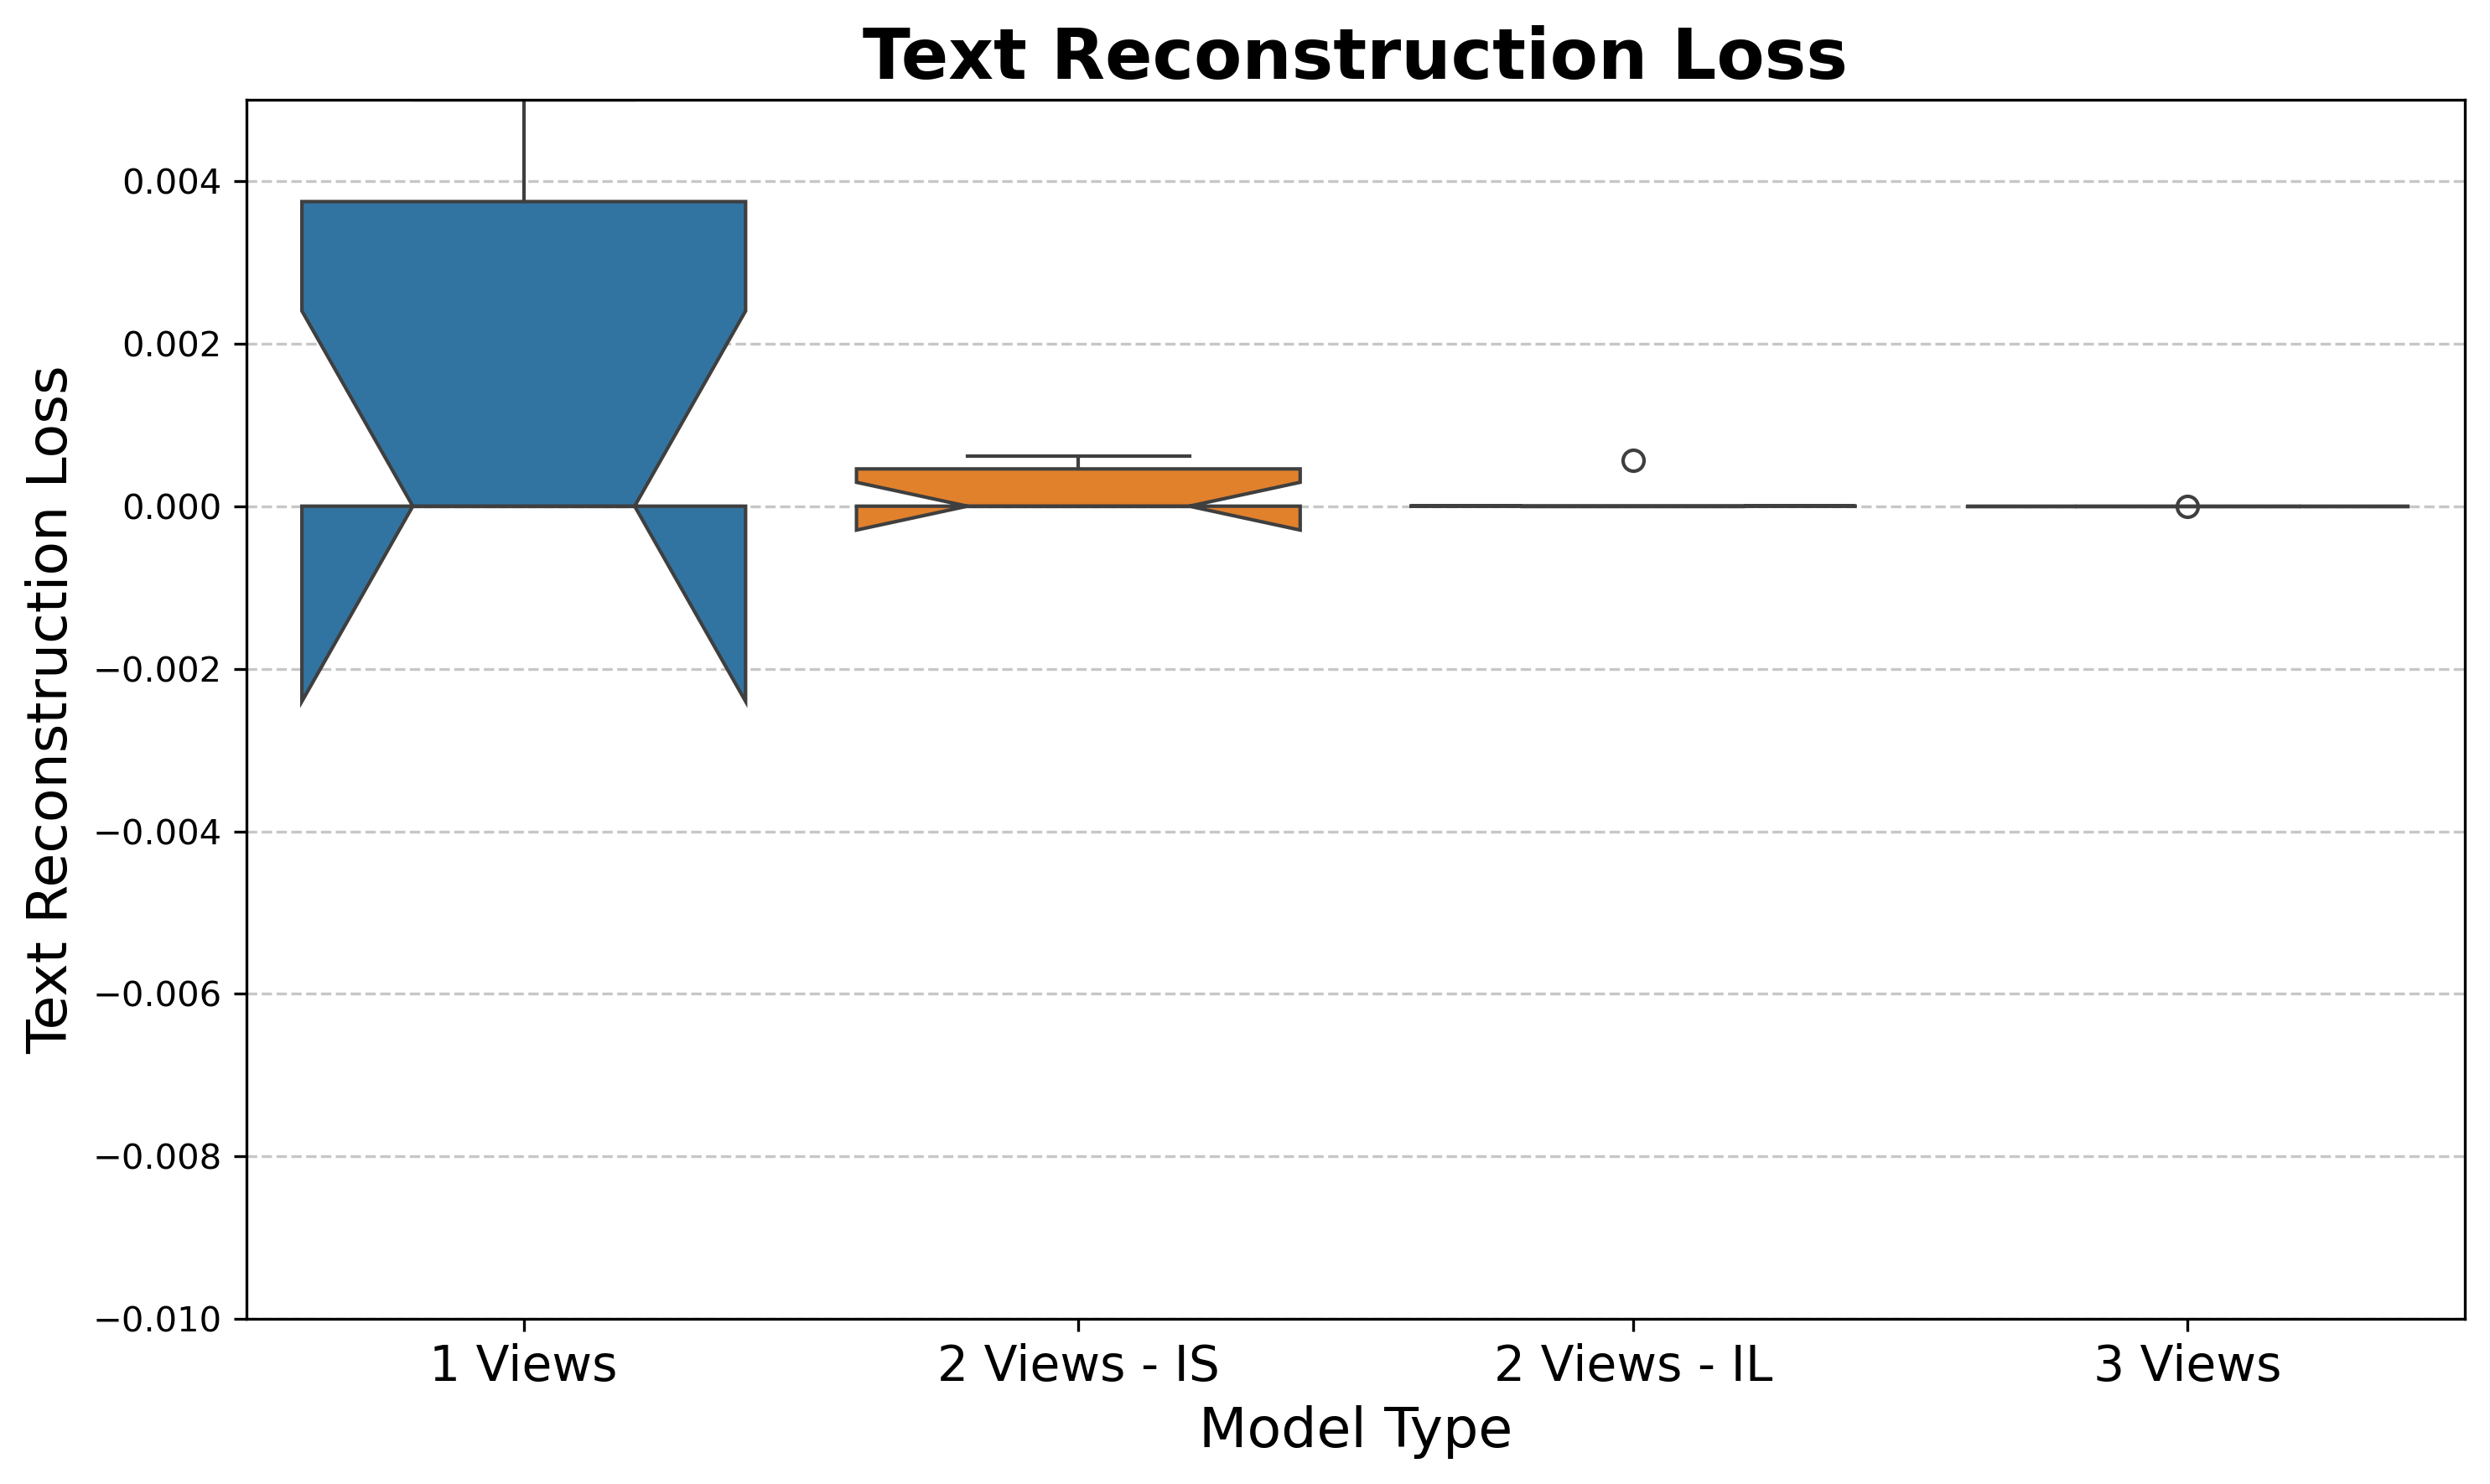

In [24]:
plt.figure(figsize=(10, 6), dpi=300)

sns.boxplot(data=df, x="model", y="loss", notch=True, palette=['tab:blue', 'tab:orange', '#ffb066', 'tab:red'], hue="model")

plt.xlabel("Model Type", fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel("Text Reconstruction Loss", fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Text Reconstruction Loss", fontsize=20, fontweight='bold')

plt.ylim(-0.01, 0.005)

plt.tight_layout()
# plt.savefig('./img/text_reconstruction_loss_boxplot.png', dpi=300)
plt.show()

In [25]:
print('--- Text View Reconstruction Examples ---')
for i in range(10):
    pred_tokens_1V = torch.argmax(text_de_1V, dim=-1)
    pred_tokens_2V_TS = torch.argmax(text_de_2V_TS, dim=-1)
    pred_tokens_2V_TL = torch.argmax(text_de_2V_TL, dim=-1)
    pred_tokens_3V = torch.argmax(text_de_3V, dim=-1)

    print(f' > Example {i + 1}:')
    print(f'   > Original Text:\t\t', txt_encoder.decode(all_data_text[i].cpu().numpy()))
    print(f'   > 1V Reconstruction:\t\t', txt_encoder.decode(pred_tokens_1V[i].cpu().numpy()))
    print(f'   > 2V-IS Reconstruction:\t', txt_encoder.decode(pred_tokens_2V_TS[i].cpu().numpy()))
    print(f'   > 2V-IL Reconstruction:\t', txt_encoder.decode(pred_tokens_2V_TL[i].cpu().numpy()))
    print(f'   > 3V Reconstruction:\t\t', txt_encoder.decode(pred_tokens_3V[i].cpu().numpy()))
    print()

--- Text View Reconstruction Examples ---
 > Example 1:
   > Original Text:		 with pale blue berries. in these peaceful shades--<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
   > 1V Reconstruction:		 with pale blue berries. in these peaceful shades--
   > 2V-IS Reconstruction:	 with pale blue berries. in these peaceful shades--
   > 2V-IL Reconstruction:	 with pale blue berries. in these peaceful shades--
   > 3V Reconstruction:		 with pale blue berries. in these peaceful shades--

 > Example 2:
   > Original Text:		 it flows so long as falls the rain,<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
   > 1V Reconstruction:		 it flows so long as falls the rain, walls
   > 2V-IS Reconstruction:	 it flows so long as falls the rain, through
   > 2V-IL Reconstruction:	 it flows so long as falls the rain, বিষয়ে
   > 3V Reconstruction:		 it flows so long as falls the rain,no

 > Example 3:
   > Original Text:		 and that is why, the lonesome da

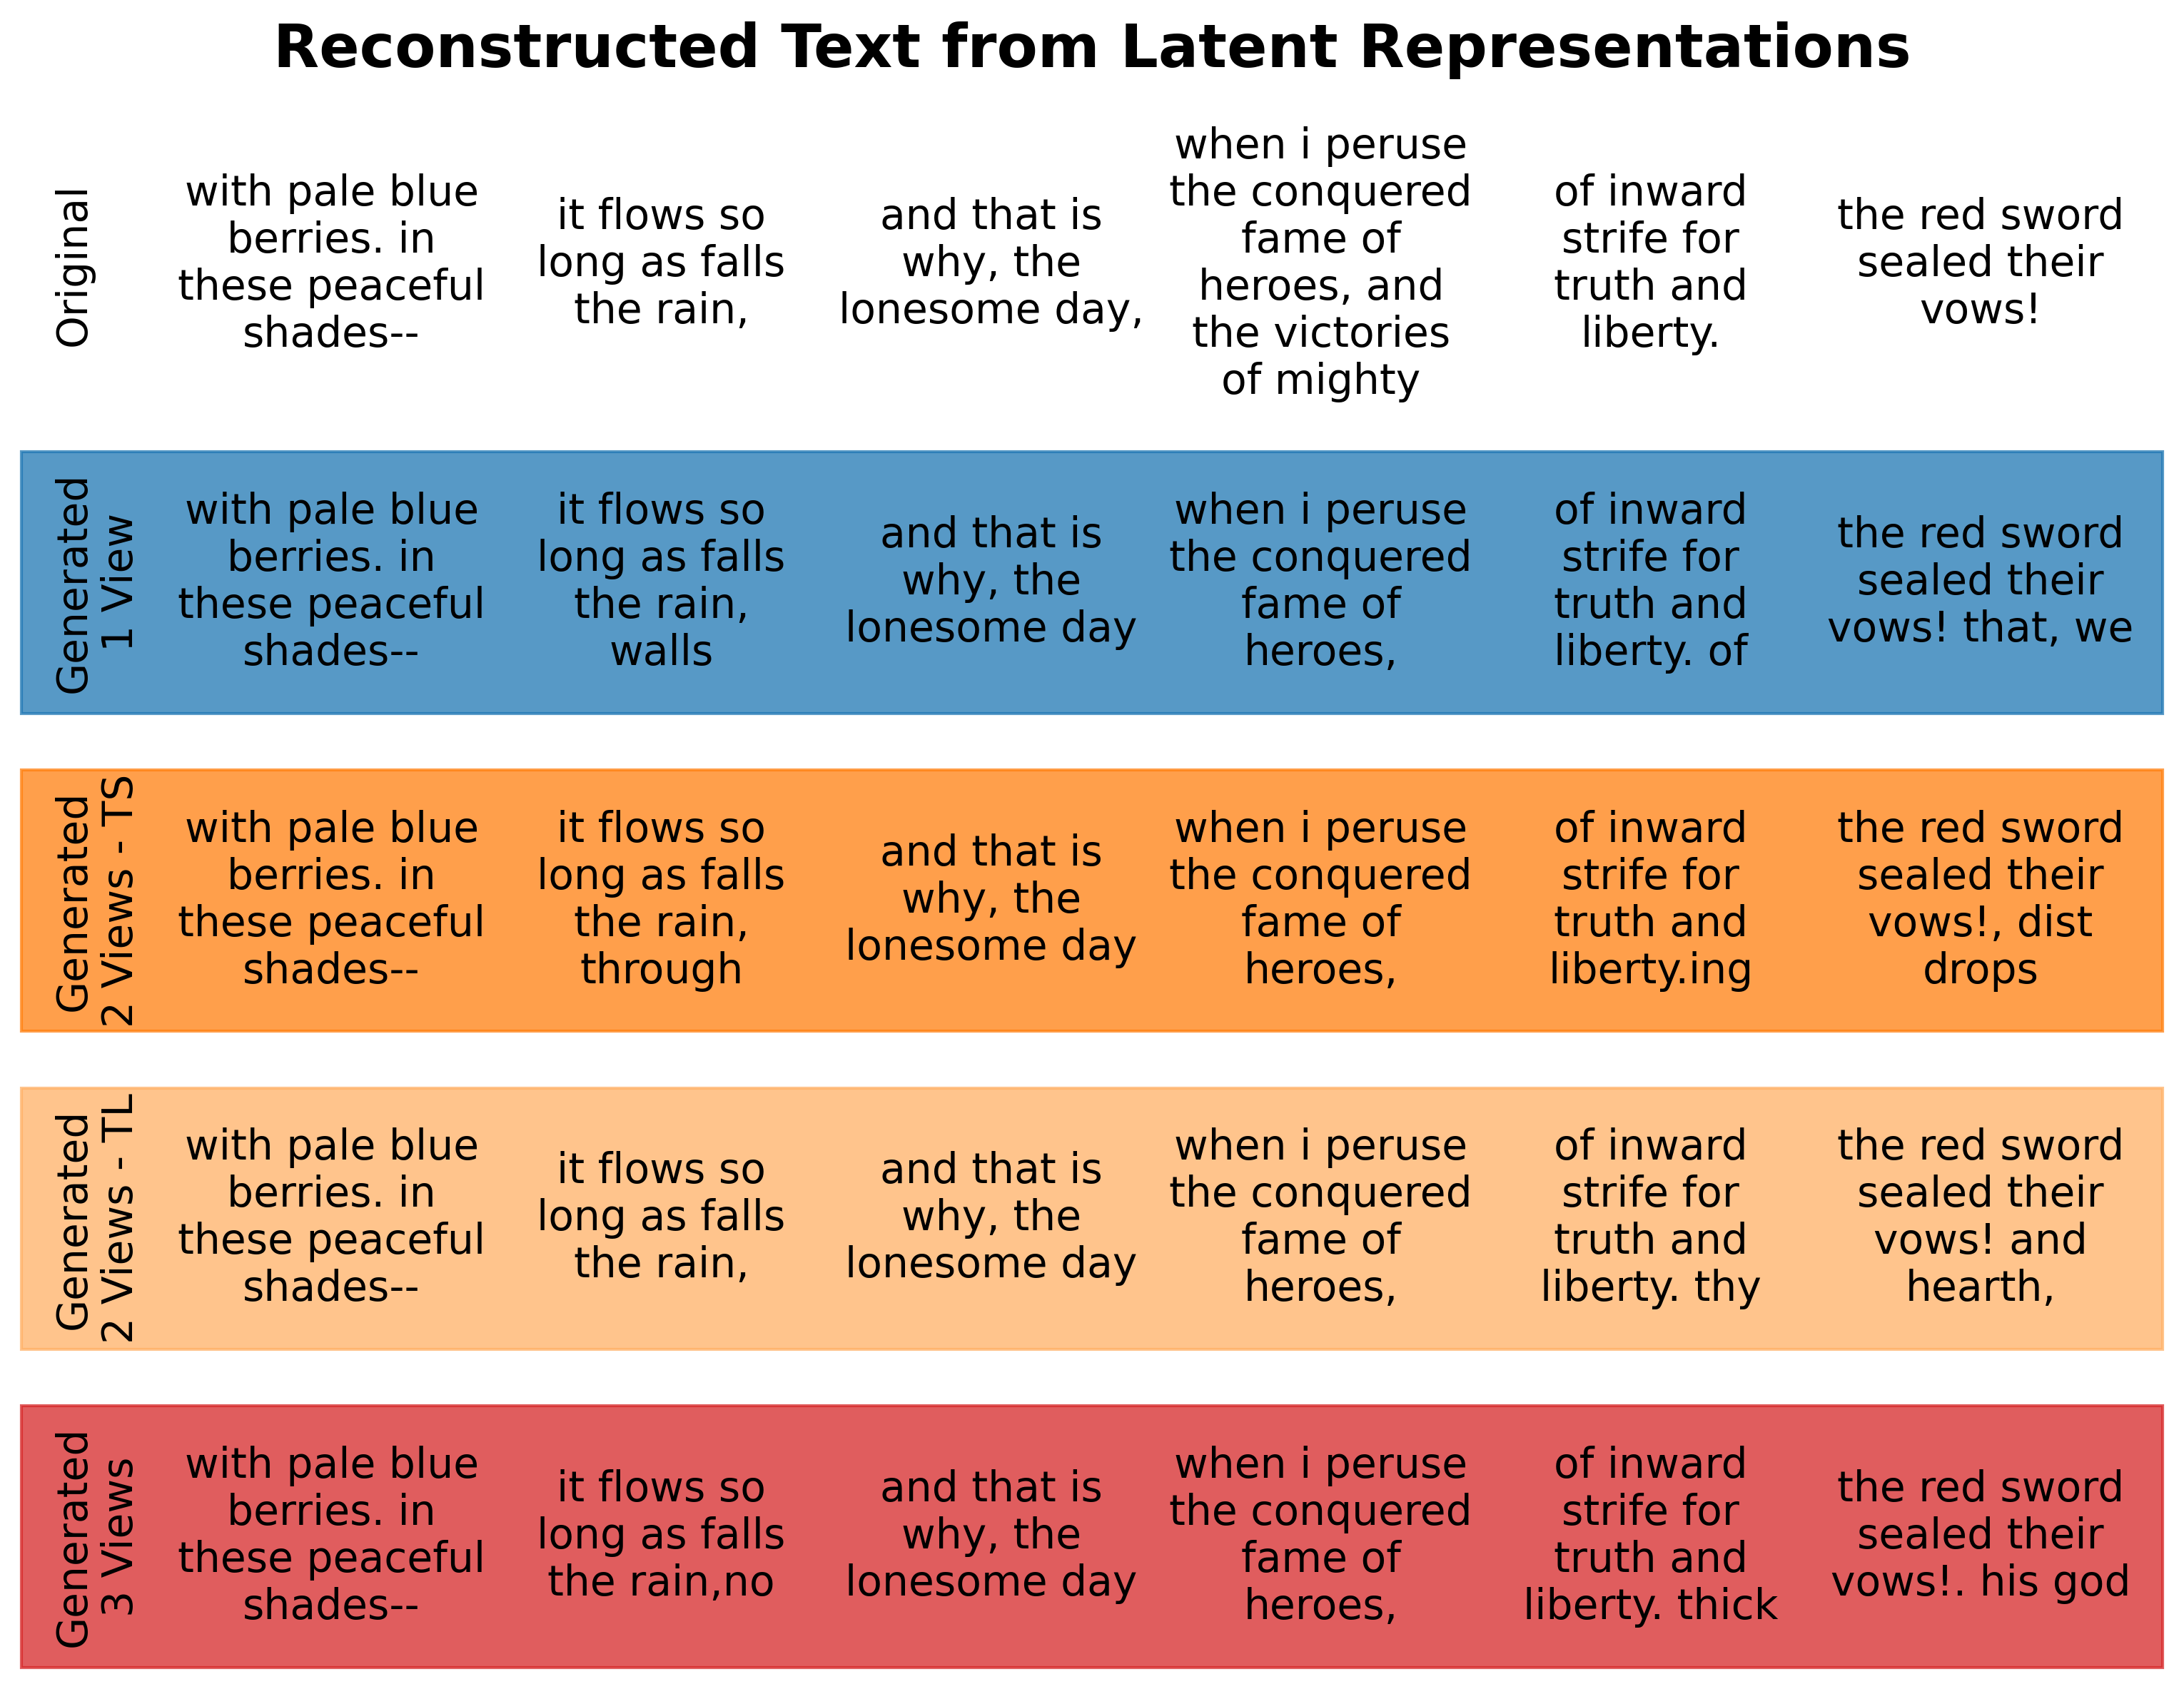

In [26]:
def clean_decoded_text(text):
    # Remove EOT marker
    text = text.replace('<|endoftext|>', '')

    # Remove non-ASCII characters such as Bengali glyphs
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Clean extra whitespace
    text = " ".join(text.split())
    return text.strip()


# Get predicted token IDs
pred_tokens_1V = torch.argmax(text_de_1V, dim=-1)
pred_tokens_2V_TS = torch.argmax(text_de_2V_TS, dim=-1)
pred_tokens_2V_TL = torch.argmax(text_de_2V_TL, dim=-1)
pred_tokens_3V = torch.argmax(text_de_3V, dim=-1)

# Number of examples to show
n_examples = 6

# Decode and clean texts
text_sets = [
    [
        clean_decoded_text(
            txt_encoder.decode(all_data_text[j].detach().cpu().numpy())
        )
        for j in range(n_examples)
    ],
    [
        clean_decoded_text(
            txt_encoder.decode(pred_tokens_1V[j].detach().cpu().numpy())
        )
        for j in range(n_examples)
    ],
    [
        clean_decoded_text(
            txt_encoder.decode(pred_tokens_2V_TS[j].detach().cpu().numpy())
        )
        for j in range(n_examples)
    ],
    [
        clean_decoded_text(
            txt_encoder.decode(pred_tokens_2V_TL[j].detach().cpu().numpy())
        )
        for j in range(n_examples)
    ],
    [
        clean_decoded_text(
            txt_encoder.decode(pred_tokens_3V[j].detach().cpu().numpy())
        )
        for j in range(n_examples)
    ]
]

row_labels = [
    'Original\n',
    'Generated\n1 View',
    'Generated\n2 Views - TS',
    'Generated\n2 Views - TL',
    'Generated\n3 Views'
]

row_colors = [None, 'tab:blue', 'tab:orange', '#ffb066', 'tab:red']

fig, ax = plt.subplots(5, 6, figsize=(10, 8), dpi=300)

for i in range(5):
    for j in range(n_examples):
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i, j].set_xlim(0, 1)
        ax[i, j].set_ylim(0, 1)

        for spine in ax[i, j].spines.values():
            spine.set_visible(False)

        wrapped_text = "\n".join(
            textwrap.wrap(
                text_sets[i][j],
                width=14,
                break_long_words=False
            )
        )

        ax[i, j].text(
            0.5,
            0.5,
            wrapped_text,
            ha='center',
            va='center',
            fontsize=14,
            wrap=True
        )

        ax[i, j].set_facecolor('none')

    ax[i, 0].set_ylabel(
        row_labels[i],
        fontsize=14,
        rotation=90,
        labelpad=40,
        va='center'
    )

plt.suptitle(
    'Reconstructed Text from Latent Representations',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()

# Add row background colors
for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = ax[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )

# plt.savefig('./img/reconstructed_text_comparison.png', dpi=300, transparent=True)
plt.show()

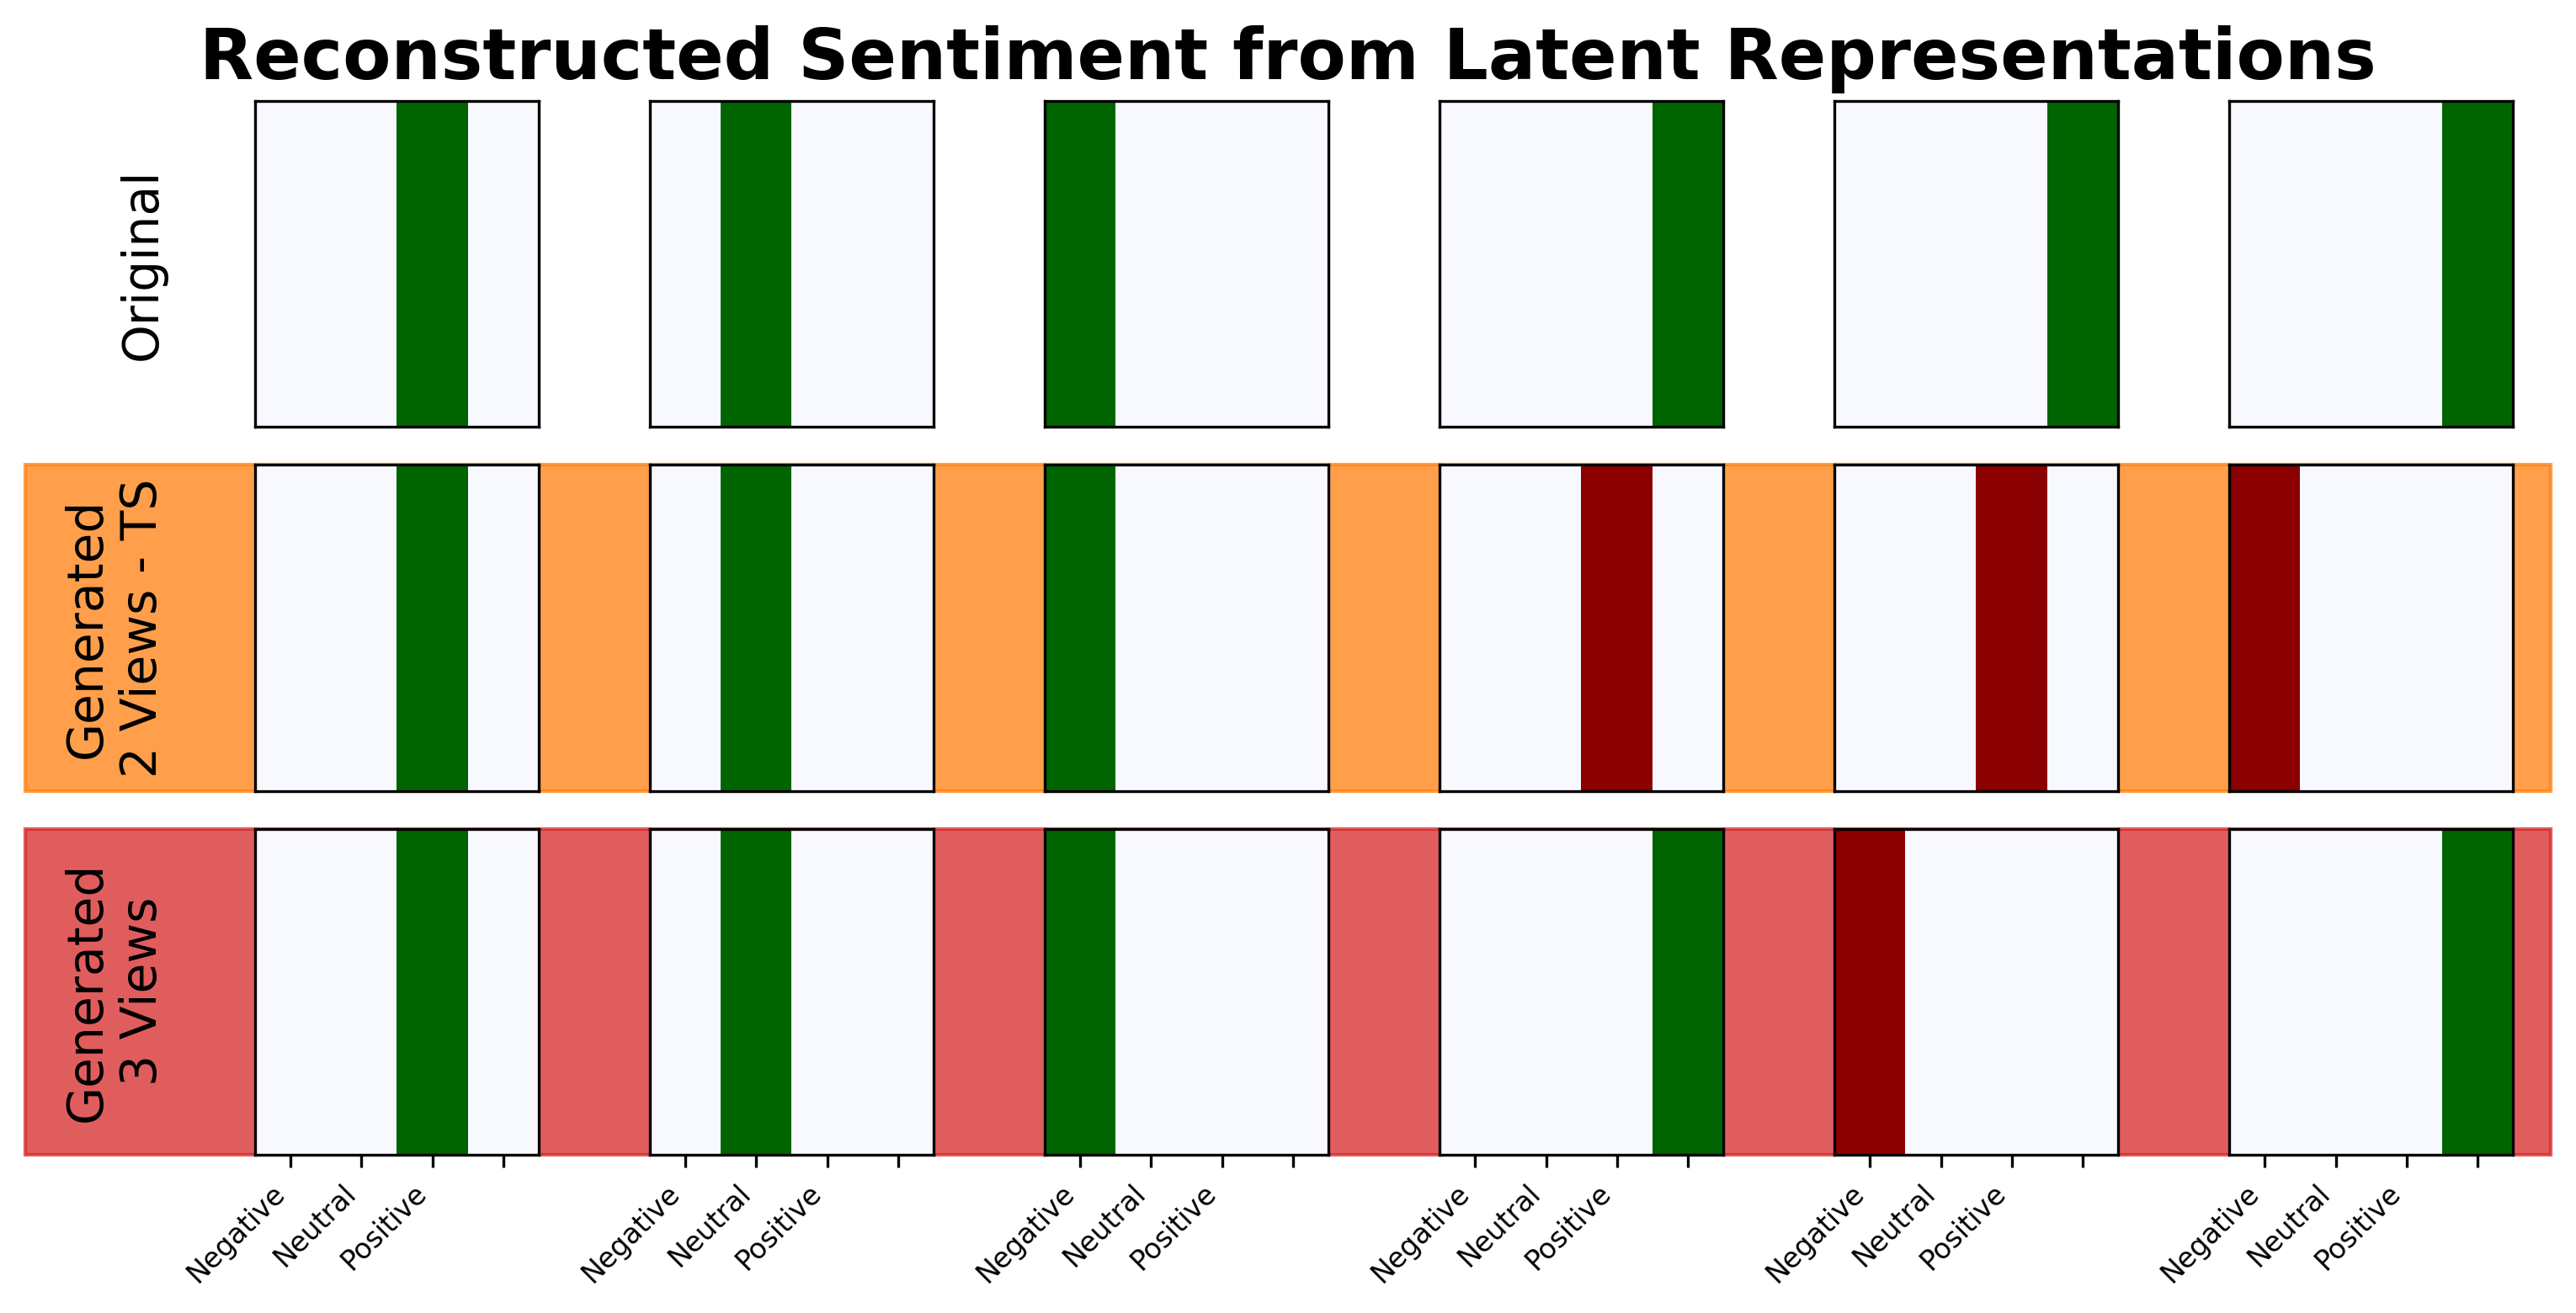

In [27]:
fig, ax = plt.subplots(3, 6, figsize=(10, 5), dpi=300)

sentiment_sets = [
    all_data_sent,
    sent_de_2V_TS,
    sent_de_3V
]

row_colors = [None, 'tab:orange', 'tab:red']

row_labels = [
    '\nOriginal',
    'Generated\n2 Views - TS',
    'Generated\n3 Views'
]

sentiment_labels = ['Negative', 'Neutral', 'Positive', '']

# Correct predictions stay green, wrong predictions become dark red
cmap_correct = ListedColormap(['ghostwhite', 'darkgreen'])
cmap_wrong = ListedColormap(['ghostwhite', 'darkred'])

def to_one_hot_sentiment(sent_vec):
    if isinstance(sent_vec, tuple):
        sent_vec = sent_vec[0]

    if torch.is_tensor(sent_vec):
        sent_vec = sent_vec.detach().cpu().numpy()
    else:
        sent_vec = np.asarray(sent_vec)

    sent_vec = sent_vec.squeeze()

    # If reconstructed outputs are probabilities/logits instead of strict one-hot vectors
    if not np.all((sent_vec == 0) | (sent_vec == 1)):
        one_hot = np.zeros_like(sent_vec)
        one_hot[np.argmax(sent_vec)] = 1
        sent_vec = one_hot

    return sent_vec

# Ground-truth classes from the original row
true_classes = []
for j in range(6):
    true_vec = to_one_hot_sentiment(all_data_sent[j])
    true_classes.append(np.argmax(true_vec))

for i in range(3):
    for j in range(6):
        sent_vec = to_one_hot_sentiment(sentiment_sets[i][j])
        pred_class = np.argmax(sent_vec)

        # Original row is always green.
        # Generated rows are dark red when prediction differs from original.
        if i == 0:
            cell_cmap = cmap_correct
        else:
            cell_cmap = cmap_correct if pred_class == true_classes[j] else cmap_wrong

        ax[i, j].imshow(
            sent_vec.reshape(1, -1),
            aspect='auto',
            vmin=0,
            vmax=1,
            cmap=cell_cmap
        )

        ax[i, j].set_facecolor('white')
        ax[i, j].set_yticks([])

        if i == 2:
            ax[i, j].set_xticks(np.arange(4))
            ax[i, j].set_xticklabels(
                sentiment_labels,
                fontsize=8,
                rotation=45,
                ha='right'
            )
        else:
            ax[i, j].set_xticks([])

    ax[i, 0].set_ylabel(
        row_labels[i],
        fontsize=14,
        rotation=90,
        labelpad=40,
        va='center'
    )

plt.tight_layout()

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = ax[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )

plt.suptitle(
    'Reconstructed Sentiment from Latent Representations',
    fontsize=20,
    fontweight='bold',
    y=1.03
)

# plt.savefig('./img/reconstructed_sentiments_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

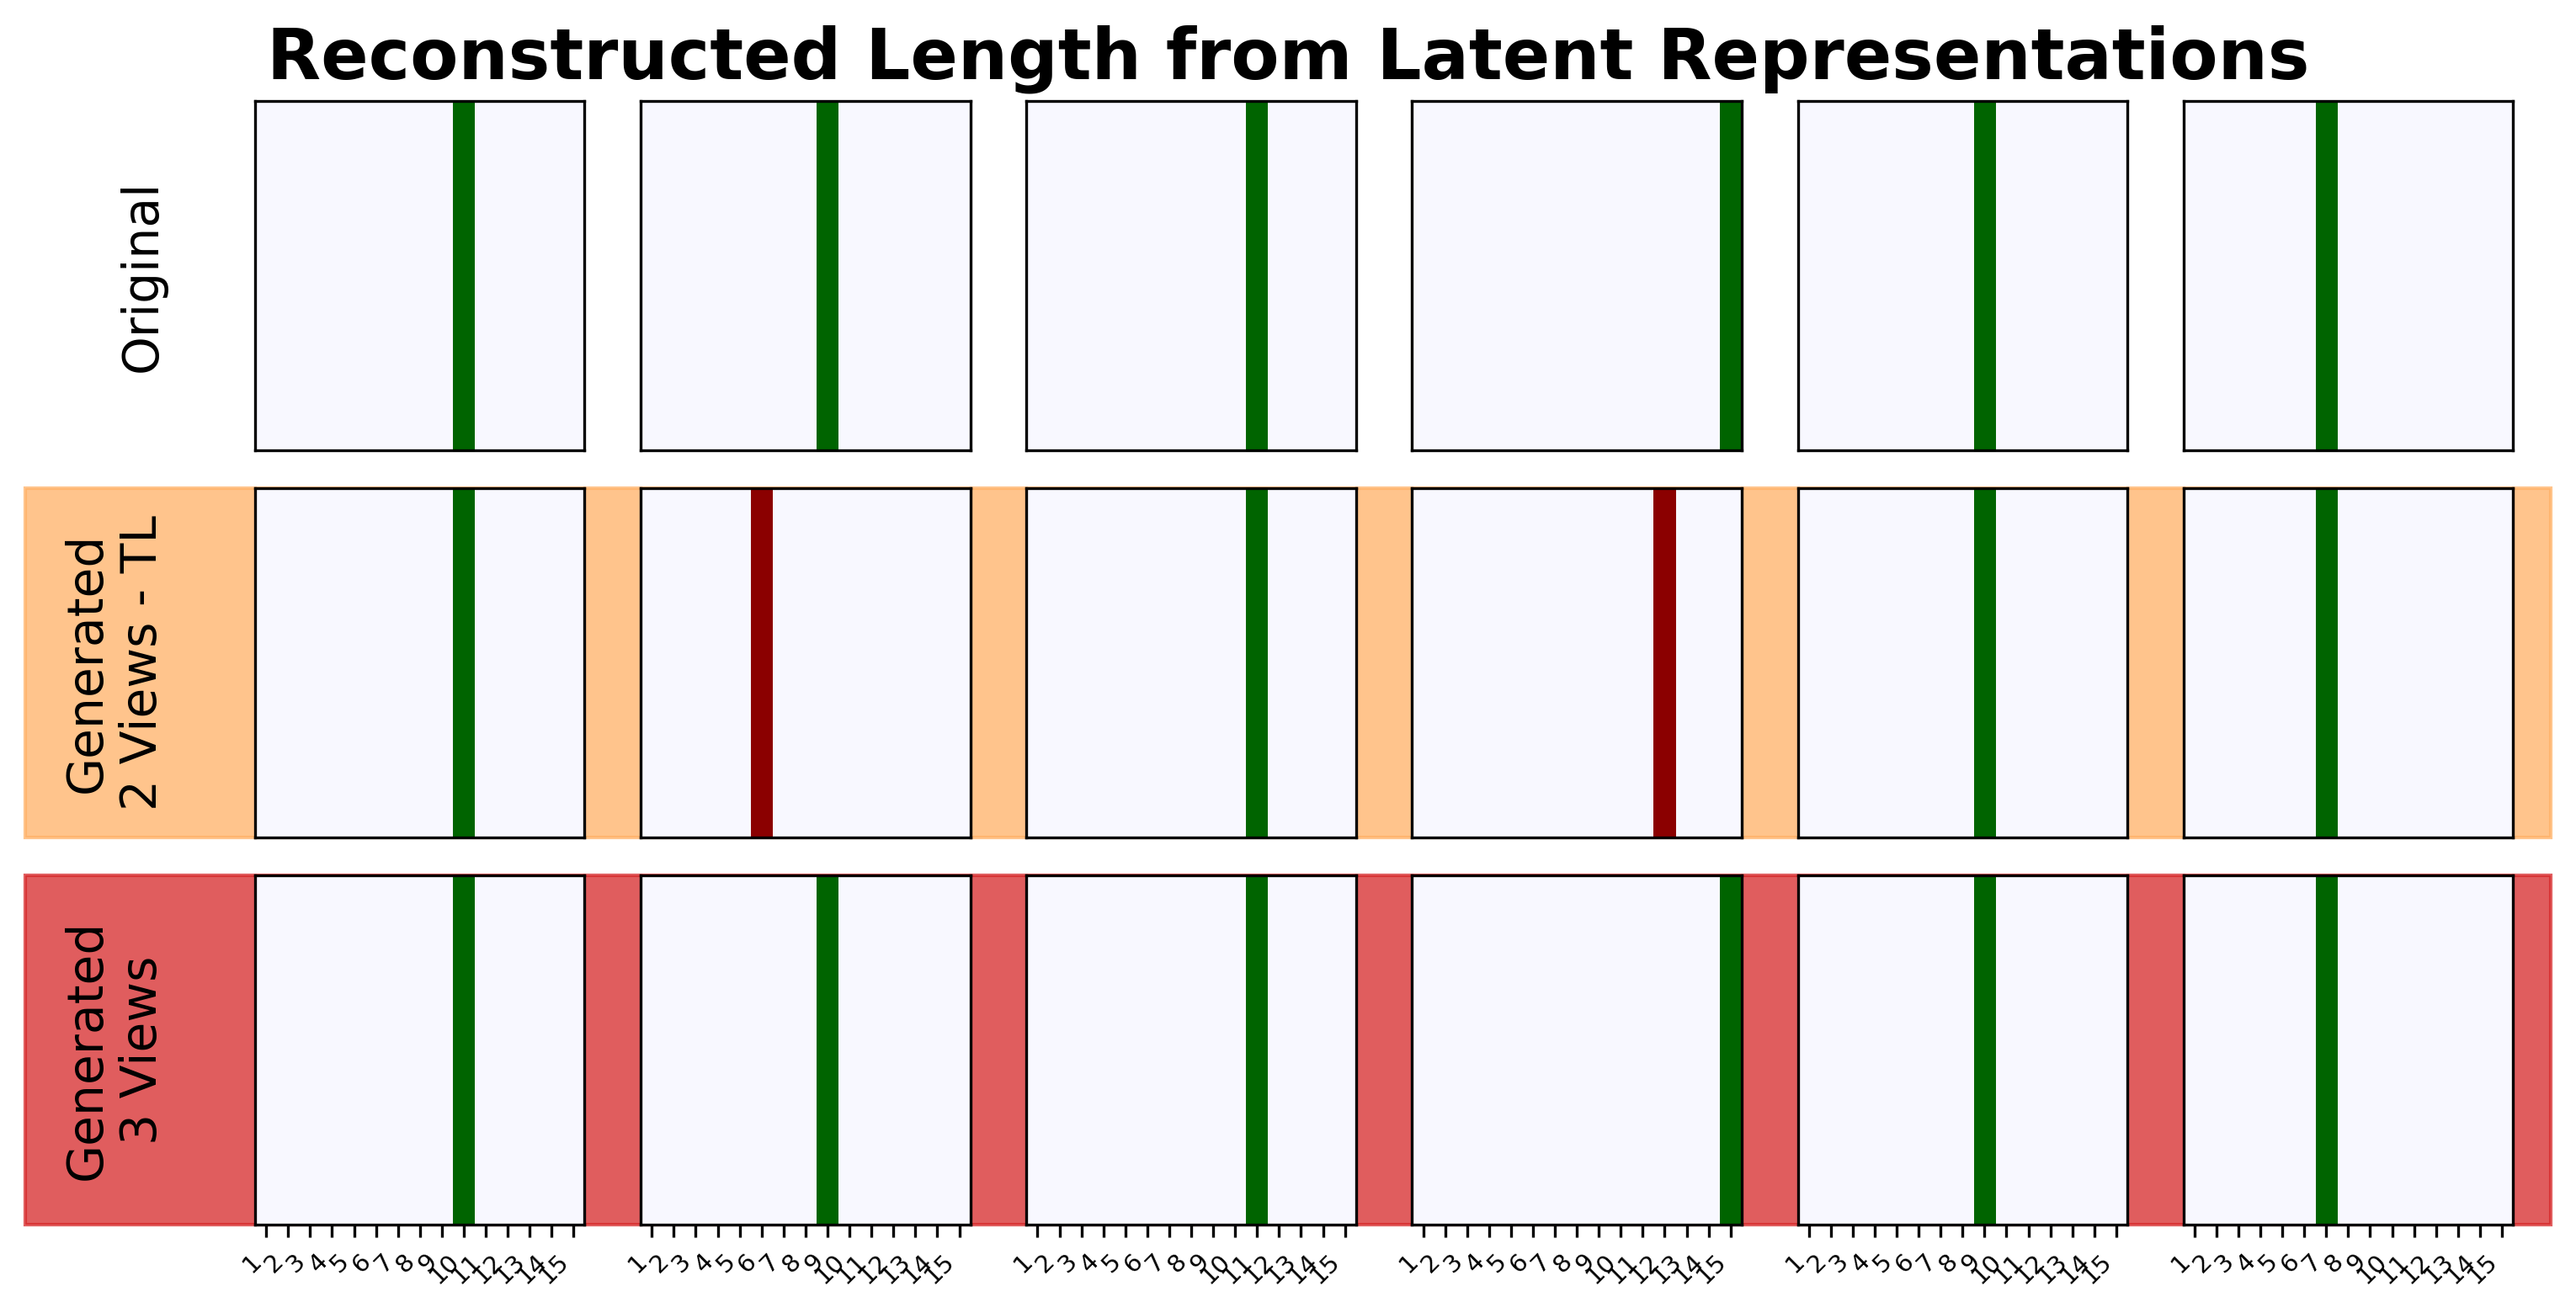

In [29]:
fig, ax = plt.subplots(3, 6, figsize=(10, 5), dpi=300)

length_sets = [
    all_data_len,
    len_de_2V_TL,
    len_de_3V
]

row_colors = [None, '#ffb066', 'tab:red']

row_labels = [
    '\nOriginal',
    'Generated\n2 Views - TL',
    'Generated\n3 Views'
]

length_labels = [str(i) for i in range(1, 16)]

# Correct predictions stay green, wrong predictions become dark red
cmap_correct = ListedColormap(['ghostwhite', 'darkgreen'])
cmap_wrong = ListedColormap(['ghostwhite', 'darkred'])

def to_one_hot_length(len_vec):
    if isinstance(len_vec, tuple):
        len_vec = len_vec[0]

    if torch.is_tensor(len_vec):
        len_vec = len_vec.detach().cpu().numpy()
    else:
        len_vec = np.asarray(len_vec)

    len_vec = len_vec.squeeze()

    # If reconstructed outputs are probabilities/logits instead of strict one-hot vectors
    if not np.all((len_vec == 0) | (len_vec == 1)):
        one_hot = np.zeros_like(len_vec)
        one_hot[np.argmax(len_vec)] = 1
        len_vec = one_hot

    return len_vec

# Ground-truth length classes from the original row
true_classes = []
for j in range(6):
    true_vec = to_one_hot_length(all_data_len[j])
    true_classes.append(np.argmax(true_vec))

for i in range(3):
    for j in range(6):
        len_vec = to_one_hot_length(length_sets[i][j])
        pred_class = np.argmax(len_vec)

        # Original row is always green.
        # Generated rows are dark red when prediction differs from original.
        if i == 0:
            cell_cmap = cmap_correct
        else:
            cell_cmap = cmap_correct if pred_class == true_classes[j] else cmap_wrong

        ax[i, j].imshow(
            len_vec.reshape(1, -1),
            aspect='auto',
            vmin=0,
            vmax=1,
            cmap=cell_cmap
        )

        ax[i, j].set_facecolor('white')
        ax[i, j].set_yticks([])

        if i == 2:
            ax[i, j].set_xticks(np.arange(15))
            ax[i, j].set_xticklabels(
                length_labels,
                fontsize=7,
                rotation=45,
                ha='right'
            )
        else:
            ax[i, j].set_xticks([])

    ax[i, 0].set_ylabel(
        row_labels[i],
        fontsize=14,
        rotation=90,
        labelpad=40,
        va='center'
    )

plt.tight_layout()

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = ax[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )

plt.suptitle(
    'Reconstructed Length from Latent Representations',
    fontsize=20,
    fontweight='bold',
    y=1.03
)

# plt.savefig('./img/reconstructed_length_comparison.png', dpi=300, bbox_inches='tight')
plt.show()